In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# make models iside src importable here. For uv this does not matter,
# or when using .venv, but does matter when using global
from util import make_dir_modules_importable
make_dir_modules_importable()

Adding: D:\Documents\Ciencias de datos\Ciencia de datos 2\PRACTICAS\uasd-ds-2\unidad01\LAB03\src to sys.path


In [10]:
# fetch data
from lab03.data import fetch_bank_note_data_from_file

backnote_auth_df = fetch_bank_note_data_from_file()

D:\Documents\Ciencias de datos\Ciencia de datos 2\PRACTICAS\uasd-ds-2\unidad01\LAB03


In [11]:
import pandas as pd

columns = list(backnote_auth_df.columns)

print("Audit of the data as it comes from repo: https://archive.ics.uci.edu/dataset/267/banknote+authentication ")
print(f"  - Columns: {columns}")
print("  - Shape: ", backnote_auth_df.shape)
print(f"  - Duplicados: {backnote_auth_df.duplicated().sum()}")

audit = pd.DataFrame({
    "tipo": backnote_auth_df.dtypes.astype(str),
    "ausentes": backnote_auth_df.isna().sum(),
    "porcentaje_ausentes": (backnote_auth_df.isna().mean()*100),
    "unicos": backnote_auth_df.nunique(dropna=False).sum()
})
audit.head(100)

Audit of the data as it comes from repo: https://archive.ics.uci.edu/dataset/267/banknote+authentication 
  - Columns: ['variance', 'skewness', 'curtosis', 'entropy', 'target']
  - Shape:  (1372, 5)
  - Duplicados: 24


,tipo,ausentes,porcentaje_ausentes,unicos
variance,float64,0,0.0,5022
skewness,float64,0,0.0,5022
curtosis,float64,0,0.0,5022
entropy,float64,0,0.0,5022
target,int64,0,0.0,5022


In [26]:
#dropping duplicates
backnote_auth_df = backnote_auth_df.drop_duplicates()

TARGET = "target"
X = backnote_auth_df.drop(columns=[TARGET])
y = backnote_auth_df[TARGET]

feature_columns = list(X.columns)
target_columns = y.name
print("Audit after removing duplicates")
print(f"  - Feature columns: {feature_columns}")
print(f"  - Target columns: {target_columns}")
print("  - Feature: ", X.shape)
print("  - Target: ", y.shape)
duplicate_count = X.duplicated().sum()
print(f"  - Target dentro de X: {y.name in X.columns}")
print(f"  - Duplicados: {duplicate_count}")
audit.head(100)

Audit after removing duplicates
  - Feature columns: ['variance', 'skewness', 'curtosis', 'entropy']
  - Target columns: target
  - Feature:  (1348, 4)
  - Target:  (1348,)
  - Target dentro de X: False
  - Duplicados: 0


,tipo,ausentes,porcentaje_ausentes,unicos
variance,float64,0,0.0,5022
skewness,float64,0,0.0,5022
curtosis,float64,0,0.0,5022
entropy,float64,0,0.0,5022
target,int64,0,0.0,5022


In [27]:
"""
this one does not apply for our dataset, but we will added here for documentation purpose. 
Since our dataset does not include null or categories other than numbers,
this will add nothing to our X values
"""
# 8. Separar tipos y crear preprocesamiento

from sklearn.compose import ColumnTransformer # to applyh transformers to columns
from sklearn.impute import SimpleImputer # Fill NaN values with the median, mean, or mode
from sklearn.pipeline import Pipeline # To chain steps
from sklearn.preprocessing import (
        OneHotEncoder, # to transform categories into numeric, ["Lima", "Quito", "Bogotá"] -> ciudad_Lima, ciudad_Quito, ciudad_Bogotá
        StandardScaler # to put units into equivaletns cuantities, SVM is sensible to units
    )

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

print(len(num_cols), len(cat_cols))

4 0


In [28]:
from sklearn.ensemble import (
    RandomForestClassifier, # ensembler de arboles de decision. Entra mchos arboles disintos con data aleatoria.
    HistGradientBoostingClassifier # esembler pero para boosting, secuencial
)
from sklearn.linear_model import LogisticRegression # clasificaion model, stronger than dummy, more simpler than SVM
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

models = {
    "logistic": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "svm_c1": Pipeline([
        ("prep", preprocess),
        ("model", SVC(C=1,probability=True,random_state=42))
    ]),
    "svm_c10": Pipeline([
        ("prep", preprocess),
        ("model", SVC(C=10,probability=True,random_state=42))
    ]),
    "rf_100": Pipeline([
        ("prep", preprocess), # max_depth=8: limita qué tan profundo puede crecer cada árbol individual
        ("model", RandomForestClassifier(n_estimators=100,max_depth=8,random_state=42,n_jobs=-1)) # n_estimators: cuántos árboles de decisión componen el "bosque".
    ]),
    "rf_300": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42,n_jobs=-1))
    ]),
    "boost": Pipeline([
        ("prep",preprocess),
        ("model",HistGradientBoostingClassifier(max_depth=6,random_state=42))
    ])
}




In [29]:
# 9. Dividir, baseline y SVM
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=42, stratify=y)
# dummy = Pipeline([
#     ("prep", preprocess),
#     ("model", DummyClassifier(strategy="most_frequent"))
# ])

# svm = Pipeline([
#     ("prep", preprocess),
#     ("model", SVC(C= 1, gamma= "scale", probability= True, random_state= 42))
# ])

# for name, model in { "dummy": dummy, "svm": svm }.items():
#     model.fit(X_train, y_train)
#     pred= model.predict(X_test)
#     print(name, f1_score(y_test, pred, average = "macro"))

# print(classification_report(y_test, svm.predict(X_test)))

In [30]:
from time import perf_counter
from pathlib import Path
import joblib, numpy as np, pandas as pd
from sklearn.metrics import f1_score, recall_score

Path("../reports/models").mkdir(parents=True,exist_ok=True)
rows=[]

for name,model in models.items():
    fit_times=[]
    for repetition in range(3):
        start = perf_counter()
        model.fit(X_train, y_train)
        fit_times.append(perf_counter() - start)

    start = perf_counter()
    pred = model.predict(X_test)
    predict_ms = (perf_counter() - start) * 1000
    path = Path("../reports/models") / f"{name}.joblib"
    joblib.dump(model, path)
    rows.append(
        {
            "model": name, "f1_macro": f1_score(y_test, pred, average="macro"),
            "recall_macro": recall_score(y_test, pred, average="macro"),
            "fit_median_s": np.median(fit_times), "predict_ms": predict_ms,
            "size_kb": path.stat().st_size/1024
        })
results=pd.DataFrame(rows)
results.sort_values("f1_macro",ascending=False)

d:\Documents\Ciencias de datos\Ciencia de datos 2\PRACTICAS\uasd-ds-2\unidad01\LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Documents\Ciencias de datos\Ciencia de datos 2\PRACTICAS\uasd-ds-2\unidad01\LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Documents\Ciencias de datos\Ciencia de datos 2\PRACTICAS\uasd-ds-2\unidad01\LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=T

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
3,rf_100,1.000000,1.000000,0.173395,31.8002,424.479492
2,svm_c10,1.000000,1.000000,0.020105,3.0063,5.568359
5,boost,1.000000,1.000000,0.215501,6.6735,330.830078
1,svm_c1,0.996264,0.996622,0.037834,5.9151,8.068359
4,rf_300,0.996264,0.996622,0.484977,62.7270,1262.291992
0,logistic,0.985086,0.986486,0.011247,3.7979,3.166016


In [31]:
# 4. Comparar PCA con y sin PCA
# PCA requiere una matriz numérica densa. Para datasets totalmente numéricos usa:
# PCA: solo funciona con números, y necesita una matriz densa (no dispersa/"sparse")
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

svm_pca = Pipeline([
 ("scale", StandardScaler()),
 ("pca", PCA(n_components=.95,random_state=42)),
 ("model", SVC(C=1,probability=True,random_state=42))
])

svm_pca.fit(X_train,y_train)
print("Componentes:",svm_pca.named_steps["pca"].n_components_)

"""
- Si tu dataset tuviera columnas categóricas, no podrías aplicar PCA directamente sobre ellas (tendrías que one-hot encodearlas primero, como en cat_pipe).
- El OneHotEncoder que usaste en preprocess genera, por defecto, una matriz dispersa (sparse) — un formato optimizado para datos con muchos ceros,
común en one-hot encoding. Pero PCA necesita una matriz densa (todos los valores explícitos) para hacer sus cálculos de varianza/covarianza.

Cuando n_components es un float entre 0 y 1, no le estás diciendo "cuántas columnas quiero", sino "qué porcentaje de la varianza (información) 
original quiero conservar".
0.95 → "quedate con la menor cantidad de componentes posible que, juntos, expliquen al menos el 95% de la varianza total de los datos originales".



"""

Componentes: 3


d:\Documents\Ciencias de datos\Ciencia de datos 2\PRACTICAS\uasd-ds-2\unidad01\LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


'\n- Si tu dataset tuviera columnas categóricas, no podrías aplicar PCA directamente sobre ellas (tendrías que one-hot encodearlas primero, como en cat_pipe).\n- El OneHotEncoder que usaste en preprocess genera, por defecto, una matriz dispersa (sparse) — un formato optimizado para datos con muchos ceros,\ncomún en one-hot encoding. Pero PCA necesita una matriz densa (todos los valores explícitos) para hacer sus cálculos de varianza/covarianza.\n\nCuando n_components es un float entre 0 y 1, no le estás diciendo "cuántas columnas quiero", sino "qué porcentaje de la varianza (información) \noriginal quiero conservar".\n0.95 → "quedate con la menor cantidad de componentes posible que, juntos, expliquen al menos el 95% de la varianza total de los datos originales".\n\n\n\n'

Shape X_num: (1348, 4)
Shape sample: (1000, 4)
Índice de X es único: True
Índice de y es único: True
¿Los índices de X e y son iguales? True
Shape y_sample: (1000, 1)
Tipo de y_sample: <class 'pandas.DataFrame'>


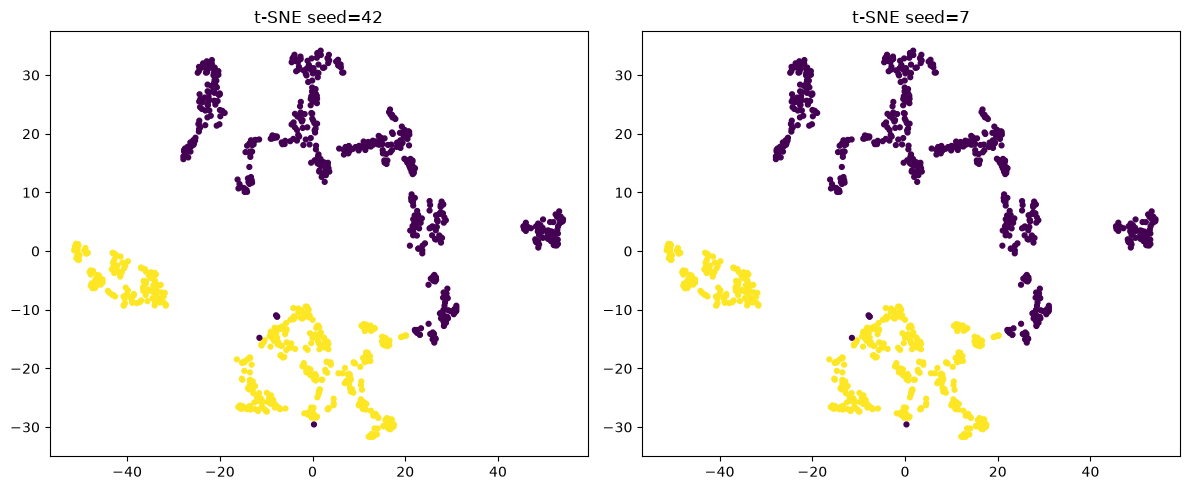

In [32]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("Shape X_num:", X_num.shape)
print("Shape sample:", sample.shape)
print("Índice de X es único:", X.index.is_unique)
print("Índice de y es único:", y.index.is_unique)
print("¿Los índices de X e y son iguales?", X.index.equals(y.index))
print("Shape y_sample:", y_sample.shape)
print("Tipo de y_sample:", type(y_sample))

X_num=X.select_dtypes(include="number").fillna(X.select_dtypes(include="number").median())
sample=X_num.sample(min(1000,len(X_num)),random_state=42)
y_sample=y.loc[sample.index]
scaled=StandardScaler().fit_transform(sample)
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,seed in zip(axes,[42,7]):
    emb=TSNE(n_components=2,perplexity=30,random_state=seed,init="pca",learning_rate="auto").fit_transform(scaled)
    ax.scatter(emb[:,0],emb[:,1],c=pd.Categorical(y_sample).codes,s=12,cmap="viridis")
    ax.set_title(f"t-SNE seed={seed}")
plt.tight_layout();plt.savefig("../reports/tsne_two_seeds.png",dpi=160)

In [35]:
def pareto_flags(df,score="f1_macro",cost="fit_median_s"):
    flags=[]
    for _,row in df.iterrows():
        dominated=((df[score]>=row[score])&(df[cost]<=row[cost])&
          ((df[score]>row[score])|(df[cost]<row[cost]))).any()
        flags.append(not bool(dominated))
    return flags

results["is_pareto"]=pareto_flags(results)
results.to_csv("../reports/green_ai_results.csv",index=False)
results.sort_values(["is_pareto","f1_macro"],ascending=[False,False])

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
2,svm_c10,1.000000,1.000000,0.020105,3.0063,5.568359,True
0,logistic,0.985086,0.986486,0.011247,3.7979,3.166016,True
3,rf_100,1.000000,1.000000,0.173395,31.8002,424.479492,False
5,boost,1.000000,1.000000,0.215501,6.6735,330.830078,False
1,svm_c1,0.996264,0.996622,0.037834,5.9151,8.068359,False
4,rf_300,0.996264,0.996622,0.484977,62.7270,1262.291992,False


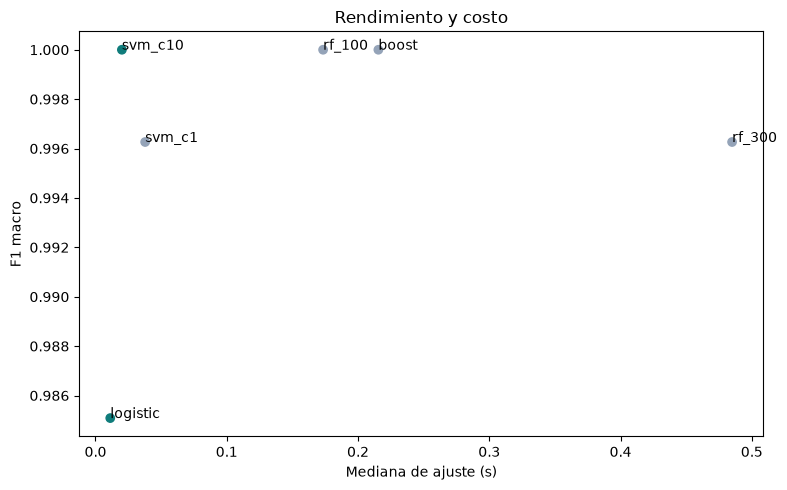

In [37]:
fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(results.fit_median_s,results.f1_macro,c=results.is_pareto.map({True:"#0f7c7b",False:"#94a3b8"}))
for _,r in results.iterrows(): ax.annotate(r.model,(r.fit_median_s,r.f1_macro))
ax.set(xlabel="Mediana de ajuste (s)",ylabel="F1 macro",title="Rendimiento y costo")
plt.tight_layout();plt.savefig("../reports/pareto.png",dpi=160)

In [38]:
import platform,sys,sklearn
print("Python",sys.version)
print("Sistema",platform.platform())
print("Procesador",platform.processor())
print("scikit-learn",sklearn.__version__)

Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Sistema Windows-11-10.0.26200-SP0
Procesador Intel64 Family 6 Model 141 Stepping 1, GenuineIntel
scikit-learn 1.9.1
